# Making Positional Embeddings 

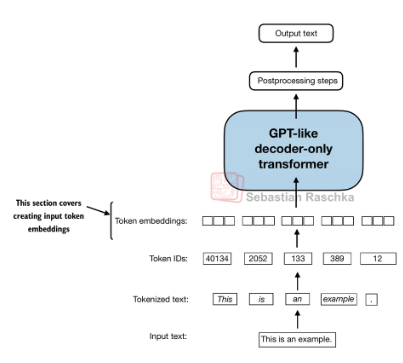

Essientially once we have the Token IDs we need to turn the token IDs into vectors inorder to adjust the parameter(weights) as we train through backpropagation. 

### Example

In [1]:
import torch

In [ ]:
input_ids = torch.tensor([2, 3, 5, 1])

#assume we only have 6 words(instead of 50K in BPE) 
#we want to create an embedding of size 3 meaning vocab described by 3 numbers
vocab_size = 6 
output_dim = 3

torch.manual_seed(123) 
#randomly initialized weights for each word in vocab (6 words, each represented by 3 numbers)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight) 

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [ ]:
#3 is the token ID and embedding layer will return the corresponding embedding vector for that token ID
# you can see it matches 4th row of weight matrix 
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [ ]:
#pass multiple token IDs and get their corresponding embedding vectors 
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


summary: 

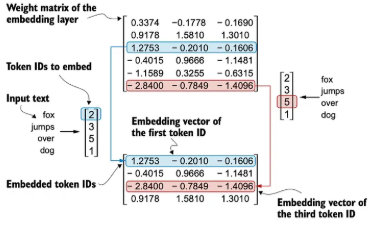

# Encoding word positions
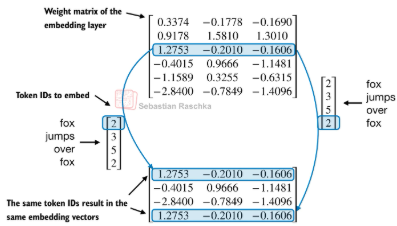
- In this example "fox" appears twice because the ID is the same so embedding layer looks up at the same row in the weight index. BOTH have same vector
- so it knows fox is in the sentence but can't discern where the word is. "fox jumps over fox"  mathematically = "to over jumps fox fox"


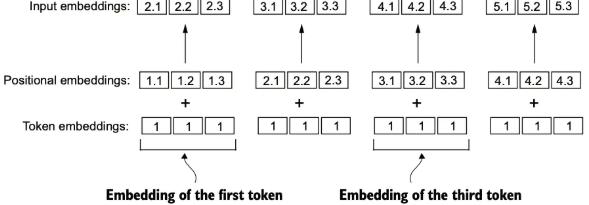

Positional embedding for each spot 

Dataloader and Dataset from previous section

In [5]:
from torch.utils.data import Dataset, DataLoader
import tiktoken


#custom dataset for input-target pairs 
class GPTDatasetV1(Dataset):
    
    def __init__(self,txt,tokenizer,max_length, stride):
        self.input_ids = [] #hold all input ids
        self.target_ids = [] #hold all corresponding target target ids (word after the input)

        token_ids = tokenizer.encode(txt) #encoding the text into token ids 

        #sliding window to get input-target pairs
        for i in range(0,len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length] #input from i -> i + max length
            target_chunk = token_ids[i+1: i+max_length+1] #target shifted by 1 spot

            #append the input and target chunks as Tensors to be used in the dataloader
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
    
#function to create dataloader from dataset
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    #intialize Byte Pair encoding tokenizer 
    tokenizer = tiktoken.get_encoding("gpt2")
    
    #create dataset(input-target paits) with txt 
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    #use dataloader to create batches of data (refer to appendix but high-level-> batches allow parallel processing and efficient training)
    dataloader = DataLoader(
        dataset, 
        batch_size = batch_size, #num of samples(input-target pairs) in each batch
        shuffle = shuffle, 
        drop_last = drop_last, # if smaller than batch size, drop the last batch
        num_workers = num_workers
    )
    return dataloader 

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

#define vocab size and embeding dimensions
vocab_size = 50527
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim) #create token embedding layer(turning token ID to vector)

max_length = 4 #input size and target size
#create dataloader with batch size of 8 and stride of 4 (non-overlapping)
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=max_length, stride=max_length, shuffle=False) 

data_iter = iter(dataloader) 
#get first batch of data (input-target pairs) from dataloader
inputs, targets = next(data_iter)
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)
#[8,4,256] -> [8 batches, 4 ID tokens per batch, 256 dimensions for each token embedding]
# each is a 256 trainable weights

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])
torch.Size([8, 4, 256])


#### Creating positional embeddings 

In [10]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

#create vector [0,1,2,3], 4 spots for 4 token input
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)
#[4,256] -> [4 positions, 256 dimensions for each position embedding]
#row 0 is the weight for being in first position, row 1 is the weight for being in second position, etc.

#adds token meaning weight with postion weight to get final input embedding 
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([4, 256])
torch.Size([8, 4, 256])
